# Volatility Models — Diagnostics & Comparison

This notebook compares three volatility regimes side by side:

| Model | Volatility Type | Key Assumption |
|---|---|---|
| **Black-Scholes** | Constant | σ is fixed forever |
| **GARCH(1,1)** | Time-varying (discrete) | σ_t depends on past shocks |
| **Heston** | Stochastic (continuous) | σ_t is its own random process |

**Goal:** Understand what each model captures, what it misses, and when to use each one.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import sys
from pathlib import Path

# Add src to path so we can import our modules
sys.path.insert(0, str(Path('..').resolve()))

from volatility_models.garch import simulate_garch
from volatility_models.stochastic_volatility import simulate_heston

print('Imports OK')

Imports OK


## 1. Shared Parameters

We use the same base parameters across all three models so comparisons are apples-to-apples.

In [12]:
# ---- Shared parameters ----
S0       = 100.0
mu       = 0.05
sigma    = 0.20      # constant vol used in BS
T        = 1.0
N        = 252       # daily steps
n_paths  = 20_000
seed     = 42

dt = T / N
v0 = sigma ** 2      # initial variance for Heston

print(f'Simulating {n_paths:,} paths over {N} daily steps ({T} year)')
print(f'Base volatility: {sigma:.0%}  |  Base variance: {v0:.4f}')

Simulating 20,000 paths over 252 daily steps (1.0 year)
Base volatility: 20%  |  Base variance: 0.0400


## 2. Simulate All Three Models

In [13]:
# ---- Model 1: Black-Scholes (constant vol GBM) ----
rng = np.random.default_rng(seed)
Z = rng.standard_normal((n_paths, N))
log_ret_BS = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
S_BS = S0 * np.exp(log_ret_BS.cumsum(axis=1))  # shape: (n_paths, N)
S_BS = np.hstack([np.full((n_paths, 1), S0), S_BS])  # prepend S0

print('Black-Scholes simulated')

Black-Scholes simulated


In [14]:
# ---- Model 2: GARCH(1,1) ----
# GARCH is a return-level model, so we simulate returns then build prices
# Run one long GARCH path and chop into n_paths segments isn't clean —
# instead we simulate independently with different seeds

garch_returns_list = []
garch_vol_list = []

for i in range(n_paths):
    r, vol, _ = simulate_garch(
        n=N,
        omega=0.0001,
        alpha=0.10,
        beta=0.85,
        mu=mu * dt,          # scale drift to daily
        sigma0=sigma * np.sqrt(dt),
        seed=seed + i,
    )
    garch_returns_list.append(r)
    garch_vol_list.append(vol)

garch_returns = np.array(garch_returns_list)  # (n_paths, N)
garch_vols    = np.array(garch_vol_list)       # (n_paths, N)

# Build price paths from returns
S_GARCH = S0 * np.exp(np.cumsum(garch_returns, axis=1))
S_GARCH = np.hstack([np.full((n_paths, 1), S0), S_GARCH])

print('GARCH simulated')

GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
GARCH(1,1) Parameters: omega=0.0001, alp

In [15]:
# ---- Model 3: Heston (stochastic vol) ----
t_grid, S_Heston, v_Heston = simulate_heston(
    S0=S0, mu=mu, v0=v0,
    kappa=2.0, theta=v0,
    xi=0.3, rho=-0.7,
    T=T, N=N, n_paths=n_paths,
    seed=seed,
)

print('Heston simulated')

Heston Model Parameters:
  kappa=2.0, theta=0.04000000000000001, xi=0.3, rho=-0.7, v0=0.04000000000000001
  Long-run vol = sqrt(theta) = 0.2000
  Feller condition (2κθ > ξ²): 0.1600 > 0.0900 → ✓
Heston simulated


## 3. Terminal Price Distributions

The most important comparison: what distribution of terminal prices does each model produce?

- **BS** → lognormal, symmetric in log space
- **GARCH** → fatter tails due to volatility clustering
- **Heston** → fatter tails + negative skew from leverage effect (rho < 0)

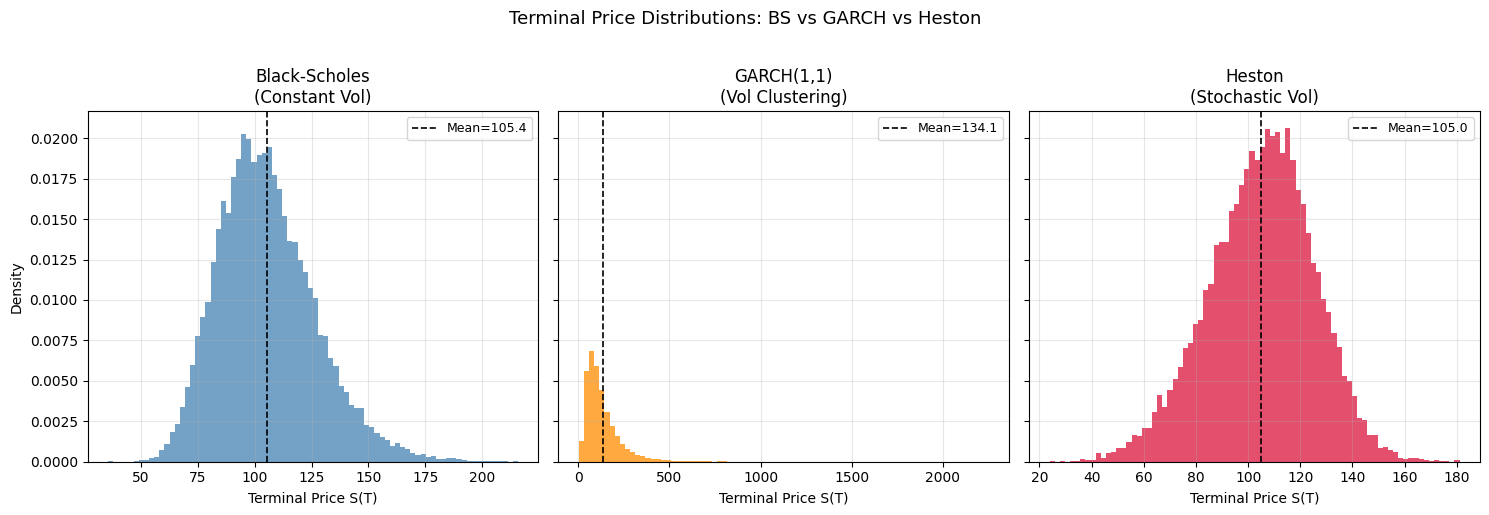

In [16]:
S_T_BS     = S_BS[:, -1]
S_T_GARCH  = S_GARCH[:, -1]
S_T_Heston = S_Heston[:, -1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, S_T, label, color in zip(
    axes,
    [S_T_BS, S_T_GARCH, S_T_Heston],
    ['Black-Scholes\n(Constant Vol)', 'GARCH(1,1)\n(Vol Clustering)', 'Heston\n(Stochastic Vol)'],
    ['steelblue', 'darkorange', 'crimson'],
):
    ax.hist(S_T, bins=80, density=True, color=color, alpha=0.75)
    ax.axvline(S_T.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean={S_T.mean():.1f}')
    ax.set_xlabel('Terminal Price S(T)')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Density')
plt.suptitle('Terminal Price Distributions: BS vs GARCH vs Heston', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/volatility_models/diagnostics_terminal_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Summary Statistics Comparison

In [17]:
import pandas as pd

# Log returns of terminal prices for statistics
logR_BS     = np.log(S_T_BS / S0)
logR_GARCH  = np.log(S_T_GARCH / S0)
logR_Heston = np.log(S_T_Heston / S0)

stats = pd.DataFrame({
    'Model':    ['Black-Scholes', 'GARCH(1,1)', 'Heston'],
    'Mean S(T)':  [S_T_BS.mean(), S_T_GARCH.mean(), S_T_Heston.mean()],
    'Std S(T)':   [S_T_BS.std(),  S_T_GARCH.std(),  S_T_Heston.std()],
    'Log-Return Mean':  [logR_BS.mean(), logR_GARCH.mean(), logR_Heston.mean()],
    'Log-Return Std':   [logR_BS.std(),  logR_GARCH.std(),  logR_Heston.std()],
    'Skewness':  [skew(logR_BS),  skew(logR_GARCH),  skew(logR_Heston)],
    'Kurtosis':  [kurtosis(logR_BS), kurtosis(logR_GARCH), kurtosis(logR_Heston)],
}).set_index('Model').round(4)

print(stats.to_string())
stats

               Mean S(T)  Std S(T)  Log-Return Mean  Log-Return Std  Skewness  Kurtosis
Model                                                                                  
Black-Scholes   105.4467   21.4519           0.0328          0.2013    0.0013    0.0286
GARCH(1,1)      134.0524  107.5746           0.0566          0.6837    0.0166    0.2337
Heston          105.0252   20.2129           0.0287          0.2081   -0.9390    1.6763


,Mean S(T),Std S(T),Log-Return Mean,Log-Return Std,Skewness,Kurtosis
Model,,,,,,
Black-Scholes,105.4467,21.4519,0.0328,0.2013,0.0013,0.0286
"GARCH(1,1)",134.0524,107.5746,0.0566,0.6837,0.0166,0.2337
Heston,105.0252,20.2129,0.0287,0.2081,-0.9390,1.6763


**What to look for:**
- **Skewness**: BS ≈ 0 (symmetric), Heston < 0 (left skew from leverage effect)
- **Kurtosis**: BS ≈ 0 (normal tails), GARCH & Heston > 0 (fat tails)
- Fat tails = more extreme outcomes than BS predicts — critical for risk management

## 5. Volatility Over Time: All Three Models

GARCH(1,1) Parameters: omega=0.0001, alpha=0.1, beta=0.85
Long-run (unconditional) volatility: 0.044721 per period
Persistence (alpha + beta):           0.9500
Heston Model Parameters:
  kappa=2.0, theta=0.04000000000000001, xi=0.3, rho=-0.7, v0=0.04000000000000001
  Long-run vol = sqrt(theta) = 0.2000
  Feller condition (2κθ > ξ²): 0.1600 > 0.0900 → ✓


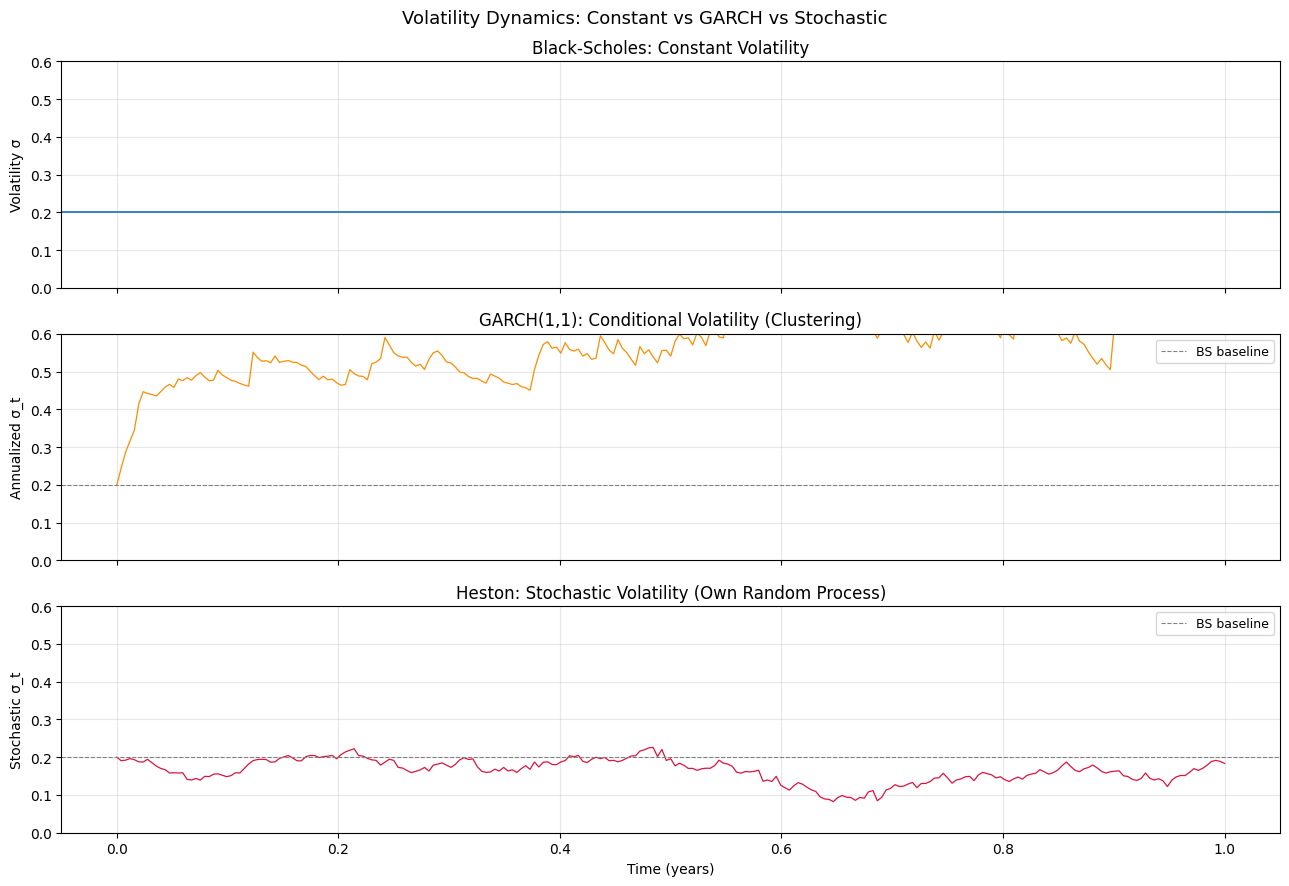

In [18]:
# Show how each model's 'volatility' behaves over a single path
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

t_axis = np.linspace(0, T, N + 1)

# BS: flat line — constant vol
axes[0].axhline(sigma, color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Volatility σ')
axes[0].set_title('Black-Scholes: Constant Volatility')
axes[0].set_ylim(0, 0.6)
axes[0].grid(alpha=0.3)

# GARCH: one path of conditional vol
r_single, vol_single, _ = simulate_garch(
    n=N, omega=0.0001, alpha=0.10, beta=0.85,
    mu=mu * dt, sigma0=sigma * np.sqrt(dt), seed=seed
)
# Annualize daily GARCH vol
vol_ann = vol_single * np.sqrt(252)
axes[1].plot(t_axis[:N], vol_ann, color='darkorange', linewidth=0.9)
axes[1].axhline(sigma, color='gray', linestyle='--', linewidth=0.8, label='BS baseline')
axes[1].set_ylabel('Annualized σ_t')
axes[1].set_title('GARCH(1,1): Conditional Volatility (Clustering)')
axes[1].set_ylim(0, 0.6)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Heston: stochastic vol path
t_h, S_h1, v_h1 = simulate_heston(
    S0=S0, mu=mu, v0=v0,
    kappa=2.0, theta=v0, xi=0.3, rho=-0.7,
    T=T, N=N, n_paths=1, seed=seed
)
axes[2].plot(t_h, np.sqrt(v_h1[0]), color='crimson', linewidth=0.9)
axes[2].axhline(sigma, color='gray', linestyle='--', linewidth=0.8, label='BS baseline')
axes[2].set_ylabel('Stochastic σ_t')
axes[2].set_xlabel('Time (years)')
axes[2].set_title('Heston: Stochastic Volatility (Own Random Process)')
axes[2].set_ylim(0, 0.6)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Volatility Dynamics: Constant vs GARCH vs Stochastic', fontsize=13)
plt.tight_layout()
plt.savefig('figures/volatility_models/diagnostics_vol_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Tail Risk: Value at Risk (VaR) Comparison

If your vol model underestimates tails, your risk estimates are dangerously wrong.
Here we compare 5% VaR across all three models.

In [19]:
confidence_levels = [0.01, 0.05, 0.10]

print(f"{'Confidence':<15} {'BS VaR':>12} {'GARCH VaR':>12} {'Heston VaR':>12}")
print('-' * 55)

for cl in confidence_levels:
    var_bs     = np.percentile(logR_BS,     cl * 100)
    var_garch  = np.percentile(logR_GARCH,  cl * 100)
    var_heston = np.percentile(logR_Heston, cl * 100)
    print(f"{f'{(1-cl):.0%} VaR':<15} {var_bs:>12.4f} {var_garch:>12.4f} {var_heston:>12.4f}")

print()
print('More negative VaR = model predicts worse tail losses = more conservative risk estimate')

Confidence            BS VaR    GARCH VaR   Heston VaR
-------------------------------------------------------
99% VaR              -0.4345      -1.5292      -0.5953
95% VaR              -0.2987      -1.0642      -0.3555
90% VaR              -0.2251      -0.8147      -0.2451

More negative VaR = model predicts worse tail losses = more conservative risk estimate


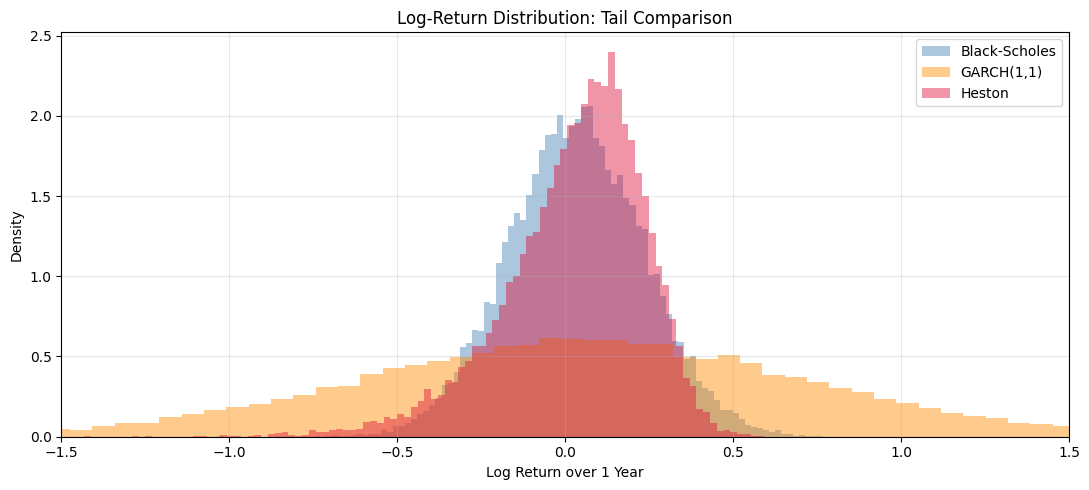

In [20]:
# ---- Visual: Tail comparison ----
fig, ax = plt.subplots(figsize=(11, 5))

for data, label, color in zip(
    [logR_BS, logR_GARCH, logR_Heston],
    ['Black-Scholes', 'GARCH(1,1)', 'Heston'],
    ['steelblue', 'darkorange', 'crimson'],
):
    ax.hist(data, bins=100, density=True, alpha=0.45, color=color, label=label)

ax.set_xlim(-1.5, 1.5)
ax.set_xlabel('Log Return over 1 Year')
ax.set_ylabel('Density')
ax.set_title('Log-Return Distribution: Tail Comparison')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/volatility_models/diagnostics_tail_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Key Takeaways

| | Black-Scholes | GARCH(1,1) | Heston |
|---|---|---|---|
| **Volatility** | Constant | Discrete, path-dependent | Continuous random process |
| **Tails** | Normal (lognormal prices) | Fatter (clustering) | Fattest (vol uncertainty) |
| **Skew** | None | Mild | Negative (leverage effect) |
| **Captures clustering** | ✗ | ✓ | ✓ |
| **Captures vol smile** | ✗ | Partially | ✓ |
| **Computational cost** | Very low | Low | Medium |
| **Best used for** | Baseline pricing | Risk management, forecasting | Options pricing, vol surface |

### The Big Idea
As you move from BS → GARCH → Heston, you're adding more realistic structure to how volatility behaves. Each step better captures what real markets look like — but at the cost of more parameters and complexity.

This understanding feeds directly into the **next section: Risk Metrics**, where accurate tail modeling matters for VaR, CVaR, and drawdown analysis.